Peaks (x): [60, 70, 80, 90, 100]
Heights (μ peaks): [0.6, 0.4, 0.2, 0.2, 0.0]
Extracted x_values: [np.float64(60.01), np.float64(70.02), np.float64(79.98), np.float64(89.99), 100]
Extracted mu_values: [np.float64(0.599), np.float64(0.399), np.float64(0.2), np.float64(0.2), np.float64(0.0)]
Defuzzified value (x*): 70.00


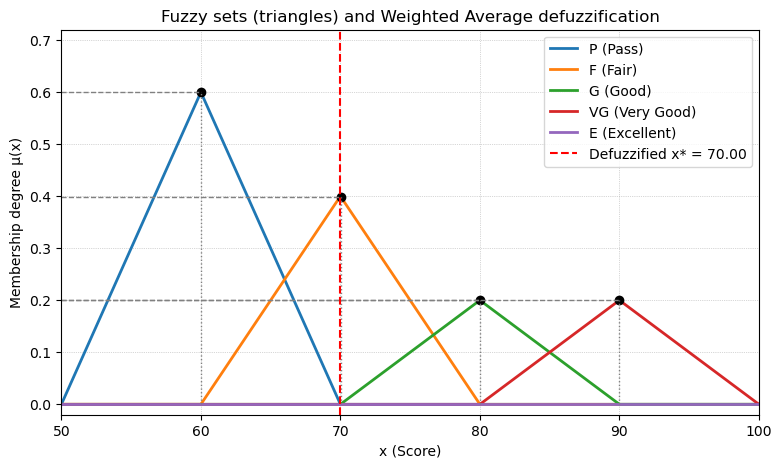

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def triangular(x, a, b, c, height=1.0):
    """
    稳健版三角隶属函数，避免除以零的情况
    """
    x = np.array(x, dtype=float)
    mu = np.zeros_like(x)

    # 左半段（上升部分）
    if b != a:
        left = (x - a) / (b - a)
    else:
        left = np.zeros_like(x)

    # 右半段（下降部分）
    if c != b:
        right = (c - x) / (c - b)
    else:
        right = np.zeros_like(x)

    mu = np.maximum(np.minimum(left, right), 0)
    mu[x == b] = 1.0
    mu = np.clip(mu, 0, 1)  # 限制范围到[0,1]
    return height * mu

# ---------- x 网格 ----------
x = np.linspace(50, 100, 1000)

# ---------- 定义每个语言变量的三角形 ----------
# 顶点位置：60, 70, 80, 90, 100
# 对应的最大隶属度：0.6, 0.4, 0.2, 0.2, 0.0
peaks = [60, 70, 80, 90, 100]
heights = [0.6, 0.4, 0.2, 0.2, 0.0]

# 为每个三角形选择左右端点（每个三角宽度为20）
mus = []
for i, p in enumerate(peaks):
    a = p - 10   # 左端
    b = p        # 顶点
    c = p + 10   # 右端
    # 对于最右侧 E（peak at 100）让右端不超过100
    if c > 100:
        c = 100
    mu = triangular(x, a, b, c, height=heights[i])
    mus.append(mu)

mu_P, mu_F, mu_G, mu_VG, mu_E = mus

# ---------- 从图形中提取每个模糊子集的最大隶属度及其对应 x（自动） ----------
mu_values = [np.max(mu) for mu in mus]
x_values = [x[np.argmax(mu)] if np.max(mu) > 0 else peaks[i] for i, mu in enumerate(mus)]
# 上面对 mu==0 的情况（如Excellent）用峰值位置作为 x 值（但权重为0，不影响计算）

# ---------- 计算加权平均去模糊化 ----------
mu_sum = np.sum(mu_values)
if mu_sum == 0:
    x_star = np.nan
else:
    x_star = np.sum(np.array(x_values) * np.array(mu_values)) / mu_sum

# ---------- 输出数值 ----------
print("Peaks (x):", peaks)
print("Heights (μ peaks):", heights)
print("Extracted x_values:", [round(v,2) for v in x_values])
print("Extracted mu_values:", [round(v,3) for v in mu_values])
print(f"Defuzzified value (x*): {x_star:.2f}")

# ---------- 绘图 ----------
plt.figure(figsize=(9,5))
plt.plot(x, mu_P, label='P (Pass)', linewidth=2)
plt.plot(x, mu_F, label='F (Fair)', linewidth=2)
plt.plot(x, mu_G, label='G (Good)', linewidth=2)
plt.plot(x, mu_VG, label='VG (Very Good)', linewidth=2)
plt.plot(x, mu_E, label='E (Excellent)', linewidth=2)

# 标出每个子集的顶点和最大隶属度的虚线
for xi, mui, lab in zip(x_values, mu_values, ['P','F','G','VG','E']):
    if mui > 0:
        plt.plot(xi, mui, 'ko')  # 标点
        plt.hlines(mui, 50, xi, colors='gray', linestyles='dashed', linewidth=1)
        plt.vlines(xi, 0, mui, colors='gray', linestyles='dotted', linewidth=1)

# 去模糊化结果线
if not np.isnan(x_star):
    plt.axvline(x_star, color='red', linestyle='--', linewidth=1.5,
                label=f'Defuzzified x* = {x_star:.2f}')

plt.xlim(50, 100)
plt.ylim(-0.02, 0.72)
plt.xlabel('x (Score)')
plt.ylabel('Membership degree μ(x)')
plt.title('Fuzzy sets (triangles) and Weighted Average defuzzification')
plt.grid(True, linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

